# Intelligent Agents: Reflex-Based Agents for GridHunt (Multi-agent Environment)

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Apply core AI concepts by implementing the agent function for a simple and model-based reflex agents that respond to environmental percepts.
* Practice how the environment and the agent function interact.
* Analyze agent performance through controlled experiments across different environment configurations.

## Instructions

Total Points: 10

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook.
### AI Use

Here are some guidelines that will make it easier for you:

* __Don't:__ Rely on AI auto completion. You will waste a lot of time trying to figure out how the suggested code relates to what we do in class. Turn off AI code completion (e.g., Copilot) in your IDE.
* __Don't:__ Do not submit code/text that you do not understand or have not checked to make sure that it is complete and correct.
* __Do:__ Use AI for debugging and letting it explain code and concepts from class.

## Introduction

![GridHunt Image](gridhunt.png)

Gridhunt is a small educational game that helps you practice implementing simple agent functions. It is a modified Python reimplementation of Gridhunt2. 

The objective of gridhunt is to implement an intelligent agent, the hunter, who can catch a monster faster than all other hunters. Gridhunt uses a $n \times n$ arena consisting of a grid of tiles. Gridhunt is a turn-based game, and several hunter agents and the monster agent move around in the arena. A hunter catches the monster if she/he moves on the same square the monster currently occupies. The hunters compete fow who catches the monster first. If the monster survives the maximum number of steps for the game, then the monster wins.

## PEAS Description of Gridhunt

__Performance Measure:__ The performance is measured as the number of steps the hunter uses to catch the monster. Catching the monster means to be on the same square.

__Environment:__ An arena with $n \times n$ squares. At the beginning the monster and the hunters are randomly placed in the arena environment. The hunters and the monster
    can move around, but cannot leave the arena. Since there are three agents involved, this is a competitive multi-agent environment.

__Actuators:__ The agent can move to an adjacent square using actions "north", "east", "west", and "south", or teleport which will move the agent 
    to a random square in the arena.

__Sensors:__ The agent can always see its location in the arena and the location of the monster.  

## The Arena Environment

The environment manages the location of the agents (hunter and monster). It initially places them in a random location and then provides them in every step with percepts (the location of the hunter and the monster) and asks them for their action. 

__A Note on positions:__
The arena is implemented as an array with row and column indices representing the position.
Positions are stored in a numpy array where `pos[0]` is the row index and `pos[1]` is the column index in the arena. North means up in this array, that is the row index gets smaller when going north. Remember indices in Python start with 0 and go to `n-1`.

In [71]:
import numpy as np
from IPython.display import clear_output
from time import sleep

def arena_environment(hunter_1_agent_function, hunter_2_agent_function, monster_agent_function, n = 30, max_steps = 100, visualize = False, animation = False):
    """
    Simulate an arena where two hunter agent tries to catch a monster agent.

    Parameters:
    hunter_1_agent_function and hunter_2_agent_function (function): A function that takes the current positions of the hunter and monster
                                      and returns the next move for the hunter ('north', 'east', 'west', 'south', 'teleport').
    monster_agent_function (function): A function that takes the current positions of the hunter and monster
                                       and returns the next move for the monster (or 'stay' to remain in place).
    n (int): The size of the arena (n x n grid).
    max_steps (int): The maximum number of steps to simulate.
    visualize (bool): Whether to visualize the arena.
    animation (bool): Whether to animate the visualization with a delay.

    Returns:
    int: The number of steps taken for the hunter to catch the monster or np.nan (not a number) if not caught.
    """
    
    # Initialize positions
    monster_pos = np.random.randint(0, n-1, size=2)
    hunter_1_pos = np.random.randint(0, n-1, size=2)
    while np.array_equal(hunter_1_pos, monster_pos):
        hunter_1_pos = np.random.randint(0, n-1, size=2)
    hunter_2_pos = np.random.randint(0, n-1, size=2)
    while np.array_equal(hunter_2_pos, monster_pos):
        hunter_2_pos = np.random.randint(0, n-1, size=2)    
    
    def move(action, position):
        """calculate new position for the agent."""
        if action == 'north':
            position[0] -= 1
        elif action == 'south':
            position[0] += 1
        elif action == 'west':
            position[1] -= 1
        elif action == 'east':
            position[1] += 1
        else:
            raise ValueError("Invalid action.")
        
        # Ensure position stays within bounds
        position = np.clip(position, 0, n-1)
        return position

    def print_arena():

        if animation:
            sleep(1)
            clear_output(wait=True)
        print(f"Step {step}:")
        print(f"Hunter 1 is at '{hunter_1_pos}'; Hunter 2 is at '{hunter_2_pos}'; Monster is at '{monster_pos}'\n")
        arena = np.full((n, n), '.', dtype=str)
        arena[monster_pos[0], monster_pos[1]] = 'M'
        arena[hunter_1_pos[0], hunter_1_pos[1]] = '1'
        arena[hunter_2_pos[0], hunter_2_pos[1]] = '2'
        print("\n".join("".join(row) for row in arena))

    for step in range(max_steps):
        if visualize:
            print_arena()
        
        # Check if hunter has caught the monster
        if np.array_equal(hunter_1_pos, monster_pos):
            if visualize:
                print(f"Hunter 1 caught the monster in {step} steps!")
            return ("1", step)
        
        if np.array_equal(hunter_2_pos, monster_pos):
            if visualize:
                print(f"Hunter 2 caught the monster in {step} steps!")
            return ("2", step)

        # Get next move from monster agent function
        monster_action = monster_agent_function(monster_pos, hunter_1_pos, hunter_2_pos)
        if monster_action != 'stay':
            monster_pos = move(monster_action, monster_pos)

        # Get next move from hunter agent function
        hunter_1_action = hunter_1_agent_function(hunter_1_pos, monster_pos)
        if hunter_1_action == 'teleport':
            hunter_1_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_1_pos = move(hunter_1_action, hunter_1_pos)

        hunter_2_action = hunter_2_agent_function(hunter_2_pos, monster_pos)
        if hunter_2_action == 'teleport':
            hunter_2_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_2_pos = move(hunter_2_action, hunter_2_pos)
    
        # print the agents' actions
        if visualize:
            print(f"Hunter 1 chose action '{hunter_1_action}'")
            print(f"Hunter 2 chose action '{hunter_2_action}'")
            print(f"Monster chose action '{monster_action}'")
            print("\n" + "="*n + "\n")

    # the hunter failed to catch the monster within max_steps
    if visualize:
        print(f"Monster won by surviving {max_steps} steps.")
    
    return ("M", np.nan)

I implement the monster here as a simple agent that moves around randomly, but mostly stays in its place. You can use AI to get a detailed explanation of how the following code works.

In [72]:
monster_actions = ["north", "east", "west", "south", "stay"]

def monster_agent_function_simple(monster_pos, hunter_1_pos, hunter_2_pos):
    return np.random.choice(monster_actions, p=[0.125, 0.125, 0.125, 0.125, 0.5])

# The Hunter Agent

Your job is to implement a simple-reflex hunter agent that can catch the monster. Remember, your agent is implemented as an agent function that get percepts and needs to return a valid action. The actions are: 

In [73]:
actions = ["north", "east", "west", "south", "teleport"]

## A Simple Example Implementation

Here is a very simple hunter that just runs around randomly and hopes that it bumps into the monster. 

In [74]:
def simple_randomized_hunter_agent_function(hunter_location, monster_location):
    return np.random.choice(actions)

Ask the agent for an action.

In [75]:
simple_randomized_hunter_agent_function([0,0], [5,5])

np.str_('north')

## Experimenting With the Agent

We can place the monster and the hunter into the environment and run a simulation by calling the environment function.

In [76]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = simple_randomized_hunter_agent_function

arena_environment(hunter_1, 
                  hunter_2, 
                  monster_agent_function_simple, 
                  n=5, max_steps=5, visualize=True, animation=True)

Step 1:
Hunter 1 is at '[0 2]'; Hunter 2 is at '[1 1]'; Monster is at '[0 2]'

..1..
.2...
.....
.....
.....
Hunter 1 caught the monster in 1 steps!


('1', 1)

Well, this was one run, maybe it was just good or bad luck this time!

Let's run an experiment with 100 runs in a $20 \times 20$ arena.  

In [77]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = simple_randomized_hunter_agent_function

steps = [arena_environment(hunter_1, 
                           hunter_2, 
                           monster_agent_function_simple, 
                           n=20, max_steps=100, visualize=False) for _ in range(100)] 
print(steps)

[('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('2', 32), ('M', nan), ('2', 41), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 37), ('1', 16), ('2', 45), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 45), ('M', nan), ('M', nan), ('1', 84), ('M', nan), ('1', 13), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 35), ('M', nan), ('2', 27), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('2', 8), ('M', nan), ('M', nan), ('M', nan), ('2', 6), ('2', 72), ('M', nan), ('2', 7), ('M', nan), ('2', 99), ('M', nan), ('M', nan), ('M', nan), ('2', 17), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 43), ('1', 59), ('M', nan), ('1', 45), ('M', nan), ('M', nan), ('1', 43), ('2', 37), ('M', nan), ('2', 36), ('M', nan), ('2', 71), ('M', nan), ('M', nan), ('1', 13), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 

We just got a list with who one and the number of steps to catch the monster for 100 simulation runs.
Let's analysis the results by counting who won how often.

In [78]:
steps = np.array(steps)

print (f"Hunter 1 won: {np.sum(steps[:,0] == "1")}")
print (f"Hunter 2 won: {np.sum(steps[:,0] == "2")}")
print (f"Monster 1 won: {np.sum(steps[:,0] == "M")}")       


Hunter 1 won: 12
Hunter 2 won: 16
Monster 1 won: 72


The random agent in not a very good hunter. You need to implement a better agent function.

# Your Agent Implementation [4 points]

Write a new hunter agent function that chases the monster. Copy the simple randomized hunter function from above and modify it using rules based on the monster's and the hunter's location. Let your hunter compete with the random agent. You can also come up with several different agents and let them compete against each other.

### Ba chiến lược thợ săn

Trong phiên bản này thợ săn **luôn thấy vị trí quái vật** ở mọi bước, nên mỗi percept đã đủ thông tin để hành động: tác tử **phản xạ đơn giản** (simple reflex) là đủ, không cần bộ nhớ. Cả ba chiến lược đều là hàm của `(hunter_location, monster_location)`.

| Chiến lược | Luật hành động |
|---|---|
| **CL1: Greedy (trục lệch nhiều)** | Đi 1 bước theo trục còn lệch **nhiều hơn** về phía quái vật. Mỗi bước giảm khoảng cách Manhattan đúng 1 (tham lam theo heuristic Manhattan như trong slide Search). Không bao giờ teleport. |
| **CL2: Greedy (hướng ngẫu nhiên)** | Chọn **ngẫu nhiên** một trong các hướng làm giảm khoảng cách. Cũng giảm 1 mỗi bước, chỉ khác thứ tự đi. Dùng làm đối chứng cho CL1. |
| **CL3: Greedy + teleport** | Nếu khoảng cách Manhattan tới quái vật **> T = 0.4·n** thì `teleport`; ngược lại đi như CL1. |

**Vì sao CL1 có thể tốt hơn CL2?** Quái vật đi ngẫu nhiên nên bước của nó làm khoảng cách tăng hay giảm tùy hướng. Khi thợ săn đã **thẳng hàng** với quái vật (một trục lệch bằng 0), trong 4 hướng quái vật đi thì 3 hướng làm khoảng cách tăng (kỳ vọng +0.25 mỗi lần quái vật đi), còn khi chưa thẳng hàng thì 2 tăng, 2 giảm (kỳ vọng 0). CL1 luôn giảm trục lớn trước nên **trì hoãn** việc thẳng hàng. Đây là lời giải thích khả dĩ cho kết quả thí nghiệm bên dưới.

In [ ]:
import numpy as np

def manhattan(a, b):
    """Khoảng cách Manhattan giữa hai ô (số bước tối thiểu trên lưới, đi 4 hướng)."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def toward_larger_axis(hunter, monster):
    """Đi 1 bước theo trục còn lệch NHIỀU hơn về phía quái vật (khoảng cách Manhattan giảm 1)."""
    dr, dc = monster[0] - hunter[0], monster[1] - hunter[1]
    if abs(dr) >= abs(dc):
        return 'south' if dr > 0 else 'north'
    return 'east' if dc > 0 else 'west'

# ---- Chiến lược 1: đuổi tham lam, ưu tiên trục lệch nhiều hơn (simple reflex, không teleport)
def hunter_greedy(hunter_location, monster_location):
    return toward_larger_axis(hunter_location, monster_location)

# ---- Chiến lược 2: đuổi tham lam nhưng chọn NGẪU NHIÊN một trong các hướng làm giảm khoảng cách
def hunter_random_axis(hunter_location, monster_location):
    options = []
    if monster_location[0] < hunter_location[0]: options.append('north')
    if monster_location[0] > hunter_location[0]: options.append('south')
    if monster_location[1] < hunter_location[1]: options.append('west')
    if monster_location[1] > hunter_location[1]: options.append('east')
    return np.random.choice(options) if options else 'north'   # options rỗng = đã trùng ô (ván đã kết thúc)

# ---- Chiến lược 3: như chiến lược 1 nhưng teleport khi quá xa (khoảng cách > T = fraction × n)
def make_hunter_teleport(arena_size, fraction=0.4):
    threshold = round(fraction * arena_size)
    def hunter_teleport(hunter_location, monster_location):
        if manhattan(hunter_location, monster_location) > threshold:
            return 'teleport'
        return toward_larger_axis(hunter_location, monster_location)
    return hunter_teleport

def make_strategies(n):
    """Ba chiến lược để so sánh trên đấu trường nxn."""
    return {
        'CL1: Greedy (trục lệch nhiều)': hunter_greedy,
        'CL2: Greedy (hướng ngẫu nhiên)': hunter_random_axis,
        'CL3: Greedy + teleport (T=0.4n)': make_hunter_teleport(n),
    }

# kiểm tra nhanh giao diện hàm: (vị trí thợ săn, vị trí quái vật) -> hành động
print(hunter_greedy([0, 0], [3, 1]), hunter_greedy([5, 5], [5, 2]), make_hunter_teleport(30)([0, 0], [29, 29]))

south west teleport


# Your Experiments [2 points]

Copy the simulation code from above and run experiments with your agent. 
Experiment with larger arenas of at least size $30 \times 30$.

### Thiết lập thí nghiệm

* **Thắng** = thợ săn đó là người bắt được quái vật trước. Mỗi ván giới hạn **100 bước** (riêng thí nghiệm đổi kích thước lớn dùng giới hạn cao hơn, có ghi chú), quái vật là `monster_agent_function_simple`. Dùng `np.random.seed(42)` để kết quả chạy lại giống nhau.
* **Đối đầu với thợ săn ngẫu nhiên** (đúng theo đề): **100 ván**, tác tử của mình là Hunter 1.
* **So sánh trực tiếp giữa các chiến lược**: **1000 ván** để có kết quả ổn định, và **đổi ghế** qua từng ván. Lý do: môi trường kiểm tra Hunter 1 trước, nên khi hai thợ săn cùng tới quái vật ở một bước thì Hunter 1 luôn được tính thắng; đổi ghế triệt tiêu lợi thế này. Dòng "CL1 vs CL1" là phép thử kiểm tra tính công bằng (phải ≈ 50–50).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- (a) Tác tử của mình vs thợ săn ngẫu nhiên: 100 ván, mình là Hunter 1 ----------
np.random.seed(42)
rows = []
for n in (20, 30, 50):
    for name, hunter in make_strategies(n).items():
        res = [arena_environment(hunter, simple_randomized_hunter_agent_function,
                                 monster_agent_function_simple, n=n, max_steps=100) for _ in range(100)]
        winner = np.array([r[0] for r in res])
        rows.append({'Đấu trường': f'{n}x{n}', 'Chiến lược': name,
                     'Tác tử của tôi thắng': int((winner == '1').sum()),
                     'Thợ săn ngẫu nhiên thắng': int((winner == '2').sum()),
                     'Quái vật thắng': int((winner == 'M').sum())})
pd.DataFrame(rows)

,Đấu trường,Chiến lược,Tác tử của tôi thắng,Thợ săn ngẫu nhiên thắng,Quái vật thắng
0,20×20,CL1: Greedy (trục lệch nhiều),98,2,0
1,20×20,CL2: Greedy (hướng ngẫu nhiên),98,2,0
2,20×20,CL3: Greedy + teleport (T=0.4n),100,0,0
3,30×30,CL1: Greedy (trục lệch nhiều),97,3,0
4,30×30,CL2: Greedy (hướng ngẫu nhiên),98,2,0
5,30×30,CL3: Greedy + teleport (T=0.4n),97,3,0
6,50×50,CL1: Greedy (trục lệch nhiều),98,2,0
7,50×50,CL2: Greedy (hướng ngẫu nhiên),98,2,0
8,50×50,CL3: Greedy + teleport (T=0.4n),100,0,0


**Nhận xét:** Cả ba chiến lược thắng thợ săn ngẫu nhiên **97–100 trên 100 ván** ở cả ba kích thước, quái vật không thắng ván nào. Thợ săn ngẫu nhiên chỉ thắng 0–3 ván nhờ may mắn. Như vậy đối thủ ngẫu nhiên quá yếu để phân biệt các chiến lược, nên cần **so sánh trực tiếp** giữa chúng (bảng tiếp theo).

In [90]:
# ---------- (b) So sánh trực tiếp giữa các chiến lược: 1000 ván, đổi ghế ----------
def duel(hunter_a, hunter_b, n, runs=1000, max_steps=100, monster=monster_agent_function_simple, seed=42):
    """Cho A và B thi đấu; đổi ghế mỗi ván. Trả về (thắng A, thắng B, quái vật thắng, số bước TB của ván có người bắt)."""
    np.random.seed(seed)
    wins_a = wins_b = wins_m = 0
    steps = []
    for i in range(runs):
        if i % 2 == 0:
            winner, s = arena_environment(hunter_a, hunter_b, monster, n=n, max_steps=max_steps); a_id, b_id = '1', '2'
        else:
            winner, s = arena_environment(hunter_b, hunter_a, monster, n=n, max_steps=max_steps); a_id, b_id = '2', '1'
        if winner == a_id: wins_a += 1
        elif winner == b_id: wins_b += 1
        else: wins_m += 1
        if winner != 'M': steps.append(s)
    return wins_a, wins_b, wins_m, (np.mean(steps) if steps else np.nan)

rows = []
for n in (20, 30, 50):
    s = make_strategies(n)
    cl1, cl2, cl3 = s['CL1: Greedy (trục lệch nhiều)'], s['CL2: Greedy (hướng ngẫu nhiên)'], s['CL3: Greedy + teleport (T=0.4n)']
    for label, a, b in [('CL1 vs CL1 (kiểm tra công bằng)', cl1, cl1), ('CL1 vs CL2', cl1, cl2),
                        ('CL3 vs CL1', cl3, cl1), ('CL3 vs CL2', cl3, cl2)]:
        wa, wb, wm, avg = duel(a, b, n)
        rows.append({'Đấu trường': f'{n}×{n}', 'Cặp đấu (A vs B)': label, 'A thắng': wa, 'B thắng': wb,
                     'Quái vật thắng': wm, 'A thắng (%)': round(100 * wa / (wa + wb), 1),
                     'Số bước TB tới khi bị bắt': round(avg, 2)})
duel_df = pd.DataFrame(rows)
duel_df

,Đấu trường,Cặp đấu (A vs B),A thắng,B thắng,Quái vật thắng,A thắng (%),Số bước TB tới khi bị bắt
0,20×20,CL1 vs CL1 (kiểm tra công bằng),487,513,0,48.7,9.38
1,20×20,CL1 vs CL2,561,439,0,56.1,10.33
2,20×20,CL3 vs CL1,731,269,0,73.1,7.28
3,20×20,CL3 vs CL2,727,273,0,72.7,7.63
4,30×30,CL1 vs CL1 (kiểm tra công bằng),498,502,0,49.8,14.60
5,30×30,CL1 vs CL2,549,451,0,54.9,14.82
6,30×30,CL3 vs CL1,755,245,0,75.5,10.57
7,30×30,CL3 vs CL2,806,194,0,80.6,10.50
8,50×50,CL1 vs CL1 (kiểm tra công bằng),492,508,0,49.2,24.73
9,50×50,CL1 vs CL2,541,459,0,54.1,25.49


**Nhận xét:**
* **Phép thử công bằng**: CL1 vs CL1 cho 48.7%, 49.8%, 49.2%, tức xấp xỉ 50–50, nên việc đổi ghế đã loại bỏ lợi thế của Hunter 1.
* **CL1 thắng CL2** ở cả ba kích thước (56.1%, 54.9%, 54.1%), nhất quán với giải thích "trì hoãn việc thẳng hàng".
* **CL3 (có teleport) thắng rõ rệt**: trước CL1 là 73.1%, 75.5%, 80.6%; trước CL2 là 72.7%, 80.6%, 82.5% (20×20, 30×30, 50×50). Ván cũng kết thúc sớm hơn (30×30: khoảng 10.5 bước so với 14.6 khi hai CL1 đấu nhau).
* Quái vật không thắng ván nào vì hai thợ săn đều đuổi liên tục.

#### Teleport có lợi hay có hại? Quét ngưỡng `T = f × n` (CL3 đấu CL1)

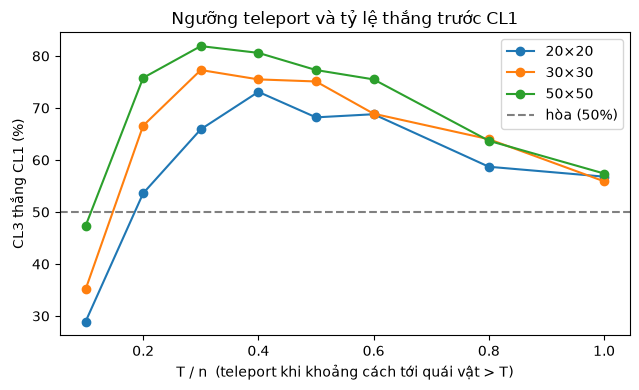

Đấu trường,20×20,30×30,50×50
T/n,,,
0.1,28.9,35.1,47.3
0.2,53.6,66.6,75.8
0.3,65.9,77.3,81.9
0.4,73.1,75.5,80.6
0.5,68.2,75.1,77.3
0.6,68.8,68.9,75.5
0.8,58.7,64.0,63.7
1.0,56.8,55.9,57.4


In [ ]:
fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
fig, ax = plt.subplots(figsize=(6.5, 4))
tele_rows = []
for n in (20, 30, 50):
    pct = []
    for f in fractions:
        wa, wb, wm, _ = duel(make_hunter_teleport(n, f), hunter_greedy, n)
        pct.append(100 * wa / (wa + wb))
        tele_rows.append({'Đấu trường': f'{n}x{n}', 'T/n': f, 'CL3 thắng CL1 (%)': round(pct[-1], 1)})
    ax.plot(fractions, pct, marker='o', label=f'{n}x{n}')
ax.axhline(50, color='gray', ls='--', label='hòa (50%)')
ax.set_xlabel('T / n  (teleport khi khoảng cách tới quái vật > T)'); ax.set_ylabel('CL3 thắng CL1 (%)')
ax.set_title('Ngưỡng teleport và tỷ lệ thắng trước CL1'); ax.legend()
plt.tight_layout(); plt.show()
pd.DataFrame(tele_rows).pivot(index='T/n', columns='Đấu trường', values='CL3 thắng CL1 (%)')

**Nhận xét về teleport:**
* **Ngưỡng tốt** khoảng `T ≈ 0.3–0.4·n`: CL3 thắng CL1 tới 73.1% (20×20, T=0.4n), 77.3% (30×30, T=0.3n), 81.9% (50×50, T=0.3n).
* **Có hại khi ngưỡng quá thấp**: với `T = 0.1n` thợ săn teleport gần như liên tục nên tỷ lệ thắng **thấp hơn 50%** (28.9%, 35.1%, 47.3%), tức thua cả CL1 vì bỏ phí tiến độ.
* **Ngưỡng quá cao** (`T = n`) gần như không kích hoạt nên lợi thế biến mất dần (khoảng 56–57%).
* Vì chỉ **người tới trước mới thắng**, thợ săn xuất phát xa quái vật gần như chắc chắn thua nếu chỉ đi bộ; teleport là cú "đánh cược" một bước để có cơ hội rơi gần quái vật hơn. Thợ săn không thấy vị trí đối thủ nên ngưỡng chỉ dựa trên khoảng cách của chính mình.

#### Ảnh hưởng của kích thước đấu trường (giới hạn 300 bước để ván ở đấu trường lớn không bị cắt)

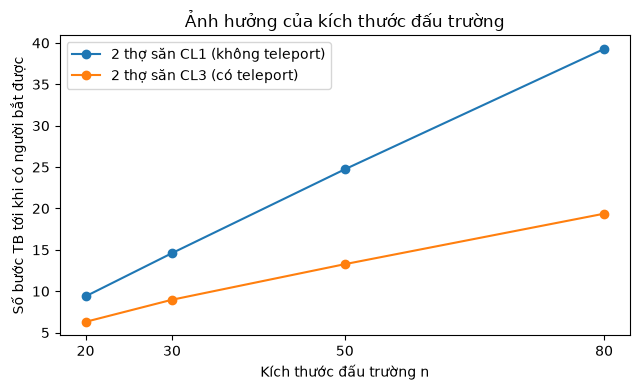

,2×CL1: số bước TB,2×CL3: số bước TB,CL3 thắng CL1 (%),Ván quái vật thắng
n,,,,
20,9.38,6.30,73.1,0
30,14.60,8.97,75.5,0
50,24.73,13.27,80.6,0
80,39.27,19.37,83.1,0


In [ ]:
def team_steps(h1, h2, n, runs=1000, max_steps=300, seed=42):
    """Số bước trung bình cho tới khi có thợ săn nào đó bắt được quái vật."""
    np.random.seed(seed)
    s = np.array([arena_environment(h1, h2, monster_agent_function_simple, n=n, max_steps=max_steps)[1]
                  for _ in range(runs)], dtype=float)
    return np.nanmean(s), int(np.isnan(s).sum())

sizes = [20, 30, 50, 80]
rows = []
for n in sizes:
    cl3 = make_hunter_teleport(n)
    t1, miss1 = team_steps(hunter_greedy, hunter_greedy, n)
    t3, miss3 = team_steps(cl3, cl3, n)
    wa, wb, wm, _ = duel(cl3, hunter_greedy, n, max_steps=300)
    rows.append({'n': n, '2xCL1: số bước TB': round(t1, 2), '2xCL3: số bước TB': round(t3, 2),
                 'CL3 thắng CL1 (%)': round(100 * wa / (wa + wb), 1), 'Ván quái vật thắng': miss1 + miss3})
size_df = pd.DataFrame(rows).set_index('n')

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(sizes, size_df['2xCL1: số bước TB'], marker='o', label='2 thợ săn CL1 (không teleport)')
ax.plot(sizes, size_df['2xCL3: số bước TB'], marker='o', label='2 thợ săn CL3 (có teleport)')
ax.set_xlabel('Kích thước đấu trường n'); ax.set_ylabel('Số bước TB tới khi có người bắt được')
ax.set_title('Ảnh hưởng của kích thước đấu trường'); ax.set_xticks(sizes); ax.legend()
plt.tight_layout(); plt.show()
size_df

**Nhận xét về kích thước đấu trường:**
* Số bước TB của **2 thợ săn CL1** tăng gần tuyến tính theo n: 9.38, 14.60, 24.73, 39.27 (n = 20, 30, 50, 80), khoảng **0.49·n**.
* Với **CL3** số bước tăng chậm hơn hẳn: 6.30, 8.97, 13.27, 19.37, tức giảm **33%, 39%, 46%, 51%** so với CL1.
* Do đó **lợi thế của teleport tăng theo kích thước**: CL3 thắng CL1 73.1% → 75.5% → 80.6% → 83.1%. Đấu trường càng rộng thì việc xuất phát "xa" càng phổ biến và teleport càng đáng giá.

## Your Conclusion [4 points] 

Discuss the following:

* What is your hunter's final strategy to choose actions. Why does it work well?
* Do you use teleportation. Why and in what situation? Why not?
* How does the arena size affects your hunter agent's performance?

> ### 1. Chiến lược chọn hành động và vì sao hiệu quả
>
> Chiến lược cuối cùng là **CL3**, một tác tử phản xạ đơn giản: **nếu khoảng cách Manhattan tới quái vật > 0.4·n thì teleport, ngược lại đi 1 bước theo trục lệch nhiều hơn về phía quái vật.**
>
> Nó hiệu quả vì:
> * Thợ săn luôn thấy quái vật nên **không cần bộ nhớ**; mỗi bước đều giảm khoảng cách Manhattan đi 1, số bước xấp xỉ khoảng cách ban đầu.
> * Chọn **trục lệch nhiều hơn** giúp CL1 thắng CL2 (đi trục ngẫu nhiên) 54–56% ván, vì trì hoãn việc thẳng hàng với quái vật (lúc đó bước ngẫu nhiên của quái vật dễ làm khoảng cách tăng hơn).
> * **Teleport khi ở xa** giúp thắng CL1 73.1% / 75.5% / 80.6% ván (20×20, 30×30, 50×50), và thắng thợ săn ngẫu nhiên 97–100 trên 100 ván.
>
> ### 2. Có dùng teleport không?
>
> **Có, chỉ khi thợ săn ở xa quái vật (> 0.4n).** Cuộc đua này là "ai tới trước thắng", nên nếu xuất phát xa mà chỉ đi bộ thì gần như chắc chắn thua; teleport tốn 1 bước và đưa tới một ô ngẫu nhiên, nhiều khả năng gần quái vật hơn, và có thể teleport lại nếu vẫn xa. **Không teleport khi đã ở gần**: khi đó đi bộ chắc chắn tiến lên, còn teleport bỏ phí tiến độ. Ngưỡng quá thấp (`0.1n`) làm tỷ lệ thắng trước CL1 tụt xuống 28.9–47.3%, thấp hơn 50%.
>
> ### 3. Kích thước đấu trường ảnh hưởng thế nào?
>
> Đấu trường càng lớn thì càng mất nhiều bước: hai thợ săn CL1 cần khoảng **0.49·n** bước (9.38 → 39.27 khi n từ 20 lên 80). Thợ săn CL3 tăng chậm hơn (6.30 → 19.37), nên **lợi thế của teleport tăng theo kích thước**: giảm 33% số bước ở 20×20 nhưng 51% ở 80×80, và tỷ lệ thắng trước CL1 tăng từ 73.1% lên 83.1%.

The monster is also an agent. Describe how the monster's agent function could be changed so it gets better at avoiding the hunter.

In [ ]:
# Quái vật chạy trốn: với xác suất p_flee, đi theo hướng làm tăng khoảng cách Manhattan tới thợ săn GẦN NHẤT;
# các bước còn lại đứng yên. (Chỉ để đo ảnh hưởng, không thay đổi môi trường.)
def make_fleeing_monster(p_flee, n):
    moves = {'north': (-1, 0), 'south': (1, 0), 'west': (0, -1), 'east': (0, 1)}
    def monster_agent_function(monster_pos, hunter_1_pos, hunter_2_pos):
        if np.random.rand() > p_flee:
            return 'stay'
        nearest = min([hunter_1_pos, hunter_2_pos], key=lambda h: manhattan(monster_pos, h))
        best, best_d = 'stay', -1
        for action, (dr, dc) in moves.items():
            new_pos = (min(max(monster_pos[0] + dr, 0), n - 1), min(max(monster_pos[1] + dc, 0), n - 1))
            d = manhattan(new_pos, nearest)
            if d > best_d or (d == best_d and np.random.rand() < 0.5):
                best, best_d = action, d
        return best
    return monster_agent_function

n = 30
cl3 = make_hunter_teleport(n)
rows = []
for label, monster in [('Đi ngẫu nhiên (mặc định)', monster_agent_function_simple)] + \
                      [(f'Chạy trốn p = {p}', make_fleeing_monster(p, n)) for p in (0.25, 0.5, 0.75, 1.0)]:
    row = {'Quái vật': label}
    for hname, h in [('2xCL1', hunter_greedy), ('2xCL3', cl3)]:
        np.random.seed(42)
        res = [arena_environment(h, h, monster, n=n, max_steps=100) for _ in range(1000)]
        row[f'{hname}: quái vật thắng /1000'] = sum(r[0] == 'M' for r in res)
        row[f'{hname}: số bước TB bị bắt'] = round(np.nanmean([r[1] for r in res]), 1)
    rows.append(row)
pd.DataFrame(rows).set_index('Quái vật')

,2×CL1: quái vật thắng /1000,2×CL1: số bước TB bị bắt,2×CL3: quái vật thắng /1000,2×CL3: số bước TB bị bắt
Quái vật,,,,
Đi ngẫu nhiên (mặc định),0,14.6,0,9.0
Chạy trốn p = 0.25,0,17.9,0,9.8
Chạy trốn p = 0.5,0,21.9,0,12.5
Chạy trốn p = 0.75,0,27.5,0,16.8
Chạy trốn p = 1.0,416,29.3,392,19.7


**Nhận xét:**
* Khi quái vật chạy trốn với xác suất `p < 1`, nó vẫn **bị bắt trong mọi ván** nhưng **sống lâu hơn**: với hai thợ săn CL1 ở 30×30, số bước tăng từ 14.6 (đi ngẫu nhiên) lên 21.9 (p = 0.5), tức tăng khoảng 50%; với CL3 từ 9.0 lên 12.5 (tăng khoảng 39%).
* Khi `p = 1.0` (quái vật chạy đều mỗi bước, tốc độ ngang thợ săn), thợ săn **không thu hẹp được khoảng cách bằng cách đi bộ**, và quái vật sống sót hết 100 bước trong **41.6%** (CL1) và **39.2%** (CL3) số ván. Đây đúng là điều đề lưu ý: đừng làm quái vật quá nhanh.

> Hàm tác tử của quái vật nhận vị trí của cả hai thợ săn (`hunter_1_pos`, `hunter_2_pos`) nên có thể được sửa để **chạy trốn** thay vì đi ngẫu nhiên:
>
> * **Chạy khỏi thợ săn gần nhất**: thử 4 hướng, chọn hướng làm khoảng cách Manhattan tới thợ săn gần nhất **lớn nhất** (hòa thì chọn ngẫu nhiên). Đây chính là tác tử được thử ở ô code phía trên.
> * **Chỉ chạy với xác suất `p < 1`** (các bước còn lại đứng yên hoặc đi ngẫu nhiên) để trò chơi vẫn còn khả năng bắt: thí nghiệm cho thấy `p = 1` thì thợ săn không đuổi kịp trong khoảng 40% số ván.
> * **Tránh tường và góc**: bước ra ngoài đấu trường bị `clip` (đứng nguyên) nên quái vật ở góc dễ bị dồn; nên ưu tiên hướng dẫn về phía khoảng trống, hoặc tính tới cả hai thợ săn thay vì chỉ một.
> * **Giữ một chút ngẫu nhiên** để thợ săn khó đoán.
>
> Hiệu quả đã đo: quái vật chạy trốn (p = 0.5) sống lâu hơn khoảng 50% so với đi ngẫu nhiên khi đối đầu 2 thợ săn CL1.

## Từ cạnh tranh sang hợp tác

**Đề xuất.** Để biến môi trường cạnh tranh thành hợp tác, đổi các yếu tố sau:

1. **Mục tiêu chung.** Hiệu năng của *đội* là số bước cho tới khi **một trong hai** thợ săn bắt được quái vật; không còn "ai thắng", hai thợ săn cùng thắng hoặc cùng thua.
2. **Chia sẻ thông tin.** Hai tác tử dùng chung một đối tượng Python (như lớp `Team` bên dưới) hoặc môi trường thêm hành động `shout` để thợ săn này nhận được thông điệp của thợ săn kia. Thông tin có thể chia sẻ: vị trí và **vai trò** của mỗi người.
3. **Phân vai.** Ví dụ người gần quái vật hơn tiếp tục đuổi để đảm bảo có tiến độ, người ở xa hơn "đánh cược" bằng teleport để có thêm cơ hội tới gần quái vật.

**Lưu ý:** trong notebook này vị trí quái vật **đã công khai** với cả hai thợ săn nên chia sẻ vị trí quái vật không thêm thông tin; điều hai thợ săn *chưa biết* là vị trí của nhau, nên thí nghiệm dưới đây chia sẻ vị trí thợ săn và phân vai. Với phiên bản quái vật bị ẩn (chỉ biết vị trí sau `listen`, như notebook đơn tác tử), chia sẻ vị trí quái vật sẽ có giá trị lớn nhất vì một lần nghe phục vụ được cả hai thợ săn (đây là đề xuất, chưa thí nghiệm ở đây).

In [ ]:
# Môi trường hợp tác: hai thợ săn CHIA SẺ vị trí của nhau qua một đối tượng dùng chung (Team).
# Mục tiêu chung: đội bắt được quái vật càng sớm càng tốt (không còn quan tâm ai bắt).
class Team:
    """Vai trò: thợ săn ở XA quái vật hơn (và xa hơn ngưỡng T) sẽ 'đánh cược' bằng teleport;
    thợ săn ở gần hơn tiếp tục đuổi để đảm bảo có tiến độ."""
    def __init__(self, threshold):
        self.threshold = threshold
        self.pos = {}                                   # vị trí mới nhất của từng thợ săn (thông tin chia sẻ)

    def agent(self, me):
        def agent_function(hunter_location, monster_location):
            self.pos[me] = np.array(hunter_location)    # công bố vị trí của mình (bản sao)
            other = self.pos.get(3 - me)                # đọc vị trí của đồng đội (nếu đã có)
            d = manhattan(hunter_location, monster_location)
            if other is not None and d > manhattan(other, monster_location) and d > self.threshold:
                return 'teleport'
            return toward_larger_axis(hunter_location, monster_location)
        return agent_function

def team_time(make_pair, n, runs=1000, max_steps=100, seed=42):
    np.random.seed(seed)
    steps = []
    for _ in range(runs):
        h1, h2 = make_pair()                            # mỗi ván tạo đội mới (Team có trạng thái)
        steps.append(arena_environment(h1, h2, monster_agent_function_simple, n=n, max_steps=max_steps)[1])
    return np.nanmean(np.array(steps, dtype=float))

rows = []
for n in (20, 30, 50):
    T = round(0.4 * n)
    cl3 = make_hunter_teleport(n)
    def make_team(T=T):
        t = Team(T); return t.agent(1), t.agent(2)
    rows.append({'Đấu trường': f'{n}x{n}',
                 '2xCL1 độc lập': round(team_time(lambda: (hunter_greedy, hunter_greedy), n), 2),
                 '2xCL3 độc lập (cùng teleport)': round(team_time(lambda: (cl3, cl3), n), 2),
                 'Team: chia sẻ vị trí + phân vai': round(team_time(make_team, n), 2)})
pd.DataFrame(rows).set_index('Đấu trường')

,2×CL1 độc lập,2×CL3 độc lập (cùng teleport),Team: chia sẻ vị trí + phân vai
Đấu trường,,,
20×20,9.38,6.30,7.72
30×30,14.60,8.97,10.81
50×50,24.73,13.27,15.78


**Kết quả** (số bước TB tới khi *đội* bắt được quái vật, thấp hơn là tốt hơn):
* Hợp tác (chia sẻ vị trí + phân vai) giảm thời gian của đội so với hai thợ săn CL1 độc lập: 9.38 → 7.72 (−18%), 14.60 → 10.81 (−26%), 24.73 → 15.78 (−36%).
* Nhưng **chưa bằng hai thợ săn CL3 độc lập** (6.30, 8.97, 13.27). Lý do: thời gian của đội là *nhỏ nhất* của hai thời gian nên đa dạng hóa có giá trị; ở CL3 cả hai đều teleport khi ở xa nên có thêm "cơ hội" rơi gần quái vật, còn trong `Team` thợ săn gần hơn không bao giờ teleport dù cũng đang ở xa.
* **Bài học:** chia sẻ thông tin chỉ có ích nếu luật dùng thông tin đó thực sự tốt hơn luật độc lập, nên phân vai cần được kiểm chứng bằng thí nghiệm. Ở môi trường này, phần lớn lợi ích đến từ teleport chứ không phải từ việc chia sẻ vị trí.

# More Work (optional)

* Improve the monster agent so it tries to run away from the hunters. Don;t make the monster too fast or the hunters will never be able to catch it.
* How could the two hunter agents work together? You need to think about information sharing. This can be implemented by the two agent functions sharing a single Python class or the environment could be expanded by an action "shout" that lets the other agent perceive a message.